In [1]:
from microsim import schema as ms
from microsim.schema.optical_config import lib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import xarray as xr
import numpy as np

In [2]:
def simulate(
    dataset,
    fluorophores,
    labels,
    channels,
    shape=(52, 512, 512),
    scale=(0.064, 0.064, 0.064),
    pinhole_au=1,
    qe=0.9,
    read_noise=3,
    max_psf_radius_aus=1,
    output_path="output.tif",
):
    """
    Simulates a microscopy dataset.

    Args:
        dataset: The COSEM dataset to use.
        fluorophores (list): List of fluorophores for each label.
        labels (list): List of labels for the COSEM dataset.
        channels (list): List of channels (e.g., [lib.DAPI, lib.FITC, lib.DSRED]).
        shape (tuple): Shape of the simulation space (z, y, x).
        scale (tuple): Scale of the simulation space in microns (z, y, x).
        pinhole_au (float): Pinhole size in Airy Units.
        qe (float): Quantum efficiency of the detector.
        read_noise (float): Read noise of the detector.
        max_psf_radius_aus (float): Maximum PSF radius in Airy Units.
        output_path (str): Path to save the output file.

    Returns:
        ms.Simulation: The simulation object.
    """
    # Ensure the number of fluorophores, labels, and channels match
    assert len(fluorophores) == len(labels) == len(channels), (
        "Number of fluorophores, labels, and channels must match!"
    )

    # Create fluorophore distributions for each channel
    fluorophore_distributions = [
        ms.FluorophoreDistribution(
            distribution=ms.CosemLabel(dataset=dataset, label=labels[i]),
            fluorophore=fluorophores[i],
        )
        for i in range(len(labels))
    ]

    # Build the simulation object
    sim = ms.Simulation(
        truth_space=ms.ShapeScaleSpace(shape=shape, scale=scale),
        sample=ms.Sample(labels=fluorophore_distributions),
        channels=channels,
        modality=ms.Confocal(pinhole_au=pinhole_au),
        detector=ms.CameraCCD(qe=qe, read_noise=read_noise, exposure_ms=5),
        output_path=output_path,
        settings=ms.Settings(max_psf_radius_aus=max_psf_radius_aus),
    )

    return sim

In [3]:
def plot_grid_with_colors(imgs, masks, threshold_mask, z, titles, colors):
    """
    Plots a grid with 2 rows (images and masks) and N columns (channels),
    using specific colors for each channel.

    Args:
        imgs (list): List of images, one per channel.
        masks (list): List of masks, one per channel.
        titles (list): Titles for each column/channel.
        colors (list): List of colors for each channel (e.g., ["cyan", "green", "magenta"]).
    """
    n_channels = len(imgs)
    fig, axes = plt.subplots(3, n_channels, figsize=(n_channels * 4, 12))
    
    for i in range(n_channels):
        # Use specific colormap for each channel
        cmap = LinearSegmentedColormap.from_list("custom", ["black", colors[i]])
        
        # Plot the image in the first row
        axes[0, i].imshow(imgs[i][z], cmap=cmap)
        axes[0, i].set_title(f"{titles[i]} - Image")
        axes[0, i].axis("off")
        
        # Plot the mask in the second row
        axes[1, i].imshow(masks[i][z], cmap=cmap)
        axes[1, i].set_title(f"{titles[i]} - Mask")
        axes[1, i].axis("off")
        
        # plot the threshold mask in the third row
        axes[2, i].imshow(threshold_mask[i][z], cmap=cmap)
        axes[2, i].set_title(f"{titles[i]} - Threshold Mask")
        axes[2, i].axis("off")
    
    plt.tight_layout()
    plt.show()

In [4]:
def threshold_mask(mask, threshold):
    # Ensure the 'f' dimension is iterable
    for idx, channel in enumerate(mask.coords["f"].values):
        # Assign positive values in the current channel to the respective index + 1
        mask.loc[dict(f=channel)] = xr.where(
            mask.sel(f=channel) > threshold, idx + 1, mask.sel(f=channel)
        )
    return mask


INFO:root:Rendering channel DAPI -----------------
INFO:root:>> fluor mTagBFP2
INFO:root:>>>> PSF @ 461.1nm (x21.77)
INFO:root:Using cached PSF: /home/sheida.rahnamai/.cache/microsim/psf/_1-515_1-515_170-0_170-0_1-515_1-515_1-0_1-4_1-47_150-0/52_513_0-064_0-064_0-4611421673598551_0-4611421673598551_1-0.npy
INFO:root:>> fluor EGFP
INFO:root:>>>> PSF @ 479.9nm (x0.16)
INFO:root:Using cached PSF: /home/sheida.rahnamai/.cache/microsim/psf/_1-515_1-515_170-0_170-0_1-515_1-515_1-0_1-4_1-47_150-0/52_513_0-064_0-064_0-4799205422927212_0-4799205422927212_1-0.npy
INFO:root:>> fluor mScarlet
INFO:root:Rendering channel FITC -----------------
INFO:root:>> fluor mTagBFP2
INFO:root:>>>> PSF @ 518.0nm (x0.01)
INFO:root:Using cached PSF: /home/sheida.rahnamai/.cache/microsim/psf/_1-515_1-515_170-0_170-0_1-515_1-515_1-0_1-4_1-47_150-0/52_513_0-064_0-064_0-5179856773508831_0-5179856773508831_1-0.npy
INFO:root:>> fluor EGFP
INFO:root:>>>> PSF @ 520.1nm (x148.06)
INFO:root:Using cached PSF: /home/sheida.r

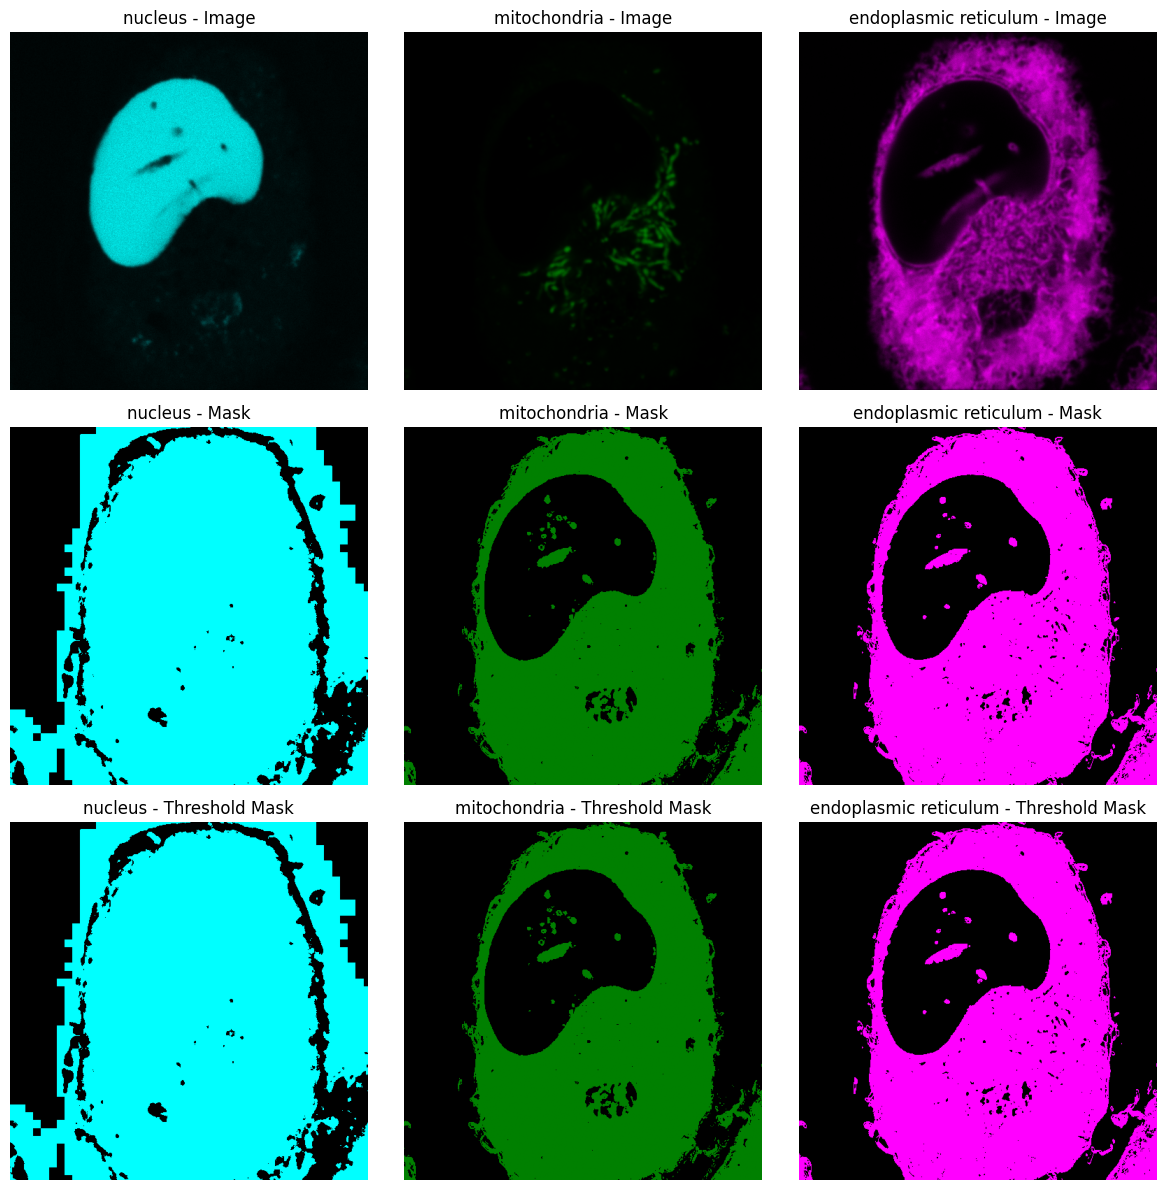

In [5]:
# Define fluorophores, labels, and channels
fluorophores = ["mTagBFP2", "EGFP", "mScarlet"]
labels = ["nucleus_pred", "mito_pred", "er_pred"]
channels = [lib.DAPI, lib.FITC, lib.DSRED]

# Run the simulation
macrophage_2_sim = simulate(
    dataset="jrc_macrophage-2",
    fluorophores=fluorophores,
    labels=labels,
    channels=channels,
    shape=(52, 512, 512),
    scale=(0.064, 0.064, 0.064),
    pinhole_au=1,
    qe=0.9,
    read_noise=3,
    max_psf_radius_aus=2,
    output_path="simulated_jrc_macrophage-2.tif",
)
macrophage_2_gt = macrophage_2_sim.ground_truth()
macrophage_2_img = macrophage_2_sim.run()
z_slice = 5
titles = ["nucleus", "mitochondria", "endoplasmic reticulum"]
colors = ["cyan", "green", "magenta"]
plot_grid_with_colors(macrophage_2_img, macrophage_2_gt, threshold_mask(macrophage_2_gt,0), z_slice, titles, colors)

In [6]:
tiff.imsave("macrophage/simulated_jrc_macrophage-2_seg.tif", macrophage_2_gt)

NameError: name 'tiff' is not defined

In [6]:
import tifffile as tiff
img = tiff.imread("/group/jug/Sheida/Microsim/macrophage/simulated_jrc_macrophage-2_source.tif")
seg = tiff.imread("/group/jug/Sheida/Microsim/macrophage/simulated_jrc_macrophage-2_gt.tif")


In [10]:
np.unique(seg[2][50])

array([0., 3.], dtype=float32)

In [12]:
np.unique(seg, return_counts=True)

(array([0., 1., 2., 3.], dtype=float32),
 array([37856937,  1242981,   326872,  1467674]))

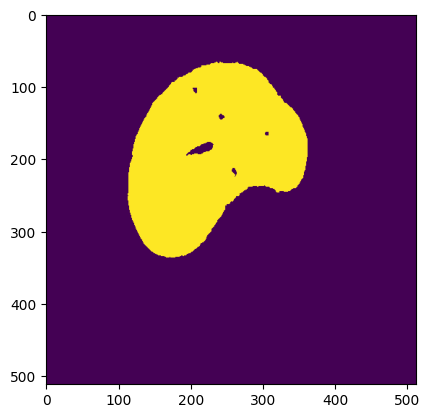

In [16]:
import matplotlib.pyplot as plt
plt.imshow(seg[0][5], cmap='viridis')

In [ ]:
# Define fluorophores, labels, and channels
fluorophores = ["mTagBFP2", "EGFP", "mScarlet"]
labels = ["nucleus_pred", "mito_pred", "er_pred"]
channels = [lib.DAPI, lib.FITC, lib.DSRED]

# Run the simulation
jrc_mus_liver_sim = simulate(
    dataset="jrc_mus-liver",
    fluorophores=fluorophores,
    labels=labels,
    channels=channels,
    shape=(52, 256, 256),
    scale=(0.064, 0.064, 0.064),
    pinhole_au=1,
    qe=0.9,
    read_noise=3,
    max_psf_radius_aus=2,
    output_path="simulation_jrc_mus-liver_on_pred.tif",
)
jrc_mus_liver_gt = jrc_mus_liver_sim.ground_truth()
jrc_mus_liver_img = jrc_mus_liver_sim.run()
z_slice = 5
titles = ["nucleus", "mitochondria", "endoplasmic reticulum"]
colors = ["cyan", "green", "magenta"]
plot_grid_with_colors(jrc_mus_liver_img, jrc_mus_liver_gt, z_slice, titles, colors)

In [ ]:
# Define fluorophores, labels, and channels
fluorophores = ["mTagBFP2", "EGFP", "mScarlet"]
labels = ["nucleus_pred", "mito_pred", "er_pred"]
channels = [lib.DAPI, lib.FITC, lib.DSRED]

# Run the simulation
jrc_choroid_plexus_2_sim = simulate(
    dataset="jrc_choroid-plexus-2",
    fluorophores=fluorophores,
    labels=labels,
    channels=channels,
    shape=(52, 192, 416),
    scale=(0.064, 0.064, 0.064),
    pinhole_au=1,
    qe=0.9,
    read_noise=3,
    max_psf_radius_aus=2,
    output_path="simulation_jrc_choroid-plexus-2_on_pred.tif",
)
jrc_choroid_plexus_2_gt = jrc_choroid_plexus_2_sim.ground_truth()
jrc_choroid_plexus_2_img = jrc_choroid_plexus_2_sim.run()
z_slice = 5
titles = ["nucleus", "mitochondria", "endoplasmic reticulum"]
colors = ["cyan", "green", "magenta"]
plot_grid_with_colors(jrc_choroid_plexus_2_img, jrc_choroid_plexus_2_gt, z_slice, titles, colors)

In [ ]:
# Define fluorophores, labels, and channels
fluorophores = ["mTagBFP2", "EGFP", "mScarlet"]
labels = ["nucleus_pred", "mito_pred", "er_pred"]
channels = [lib.DAPI, lib.FITC, lib.DSRED]

# Run the simulation
jrc_jurkat_1_sim = simulate(
    dataset="jrc_jurkat-1",
    fluorophores=fluorophores,
    labels=labels,
    channels=channels,
    shape=(52, 512, 512),
    scale=(0.064, 0.064, 0.064),
    pinhole_au=1,
    qe=0.9,
    read_noise=3,
    max_psf_radius_aus=2,
    output_path="simulation_jrc_jurkat-1_on_pred.tif",
)
jrc_jurkat_1_gt = jrc_jurkat_1_sim.ground_truth()
jrc_jurkat_1_img = jrc_jurkat_1_sim.run()
z_slice = 5
titles = ["nucleus", "mitochondria", "endoplasmic reticulum"]
colors = ["cyan", "green", "magenta"]
plot_grid_with_colors(jrc_jurkat_1_img, jrc_jurkat_1_gt, z_slice, titles, colors)